In [78]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import PowerTransformer,FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical

In [79]:
df=sns.load_dataset('diamonds')
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [80]:
df['cut'].nunique()

5

In [81]:
df.shape

(53940, 10)

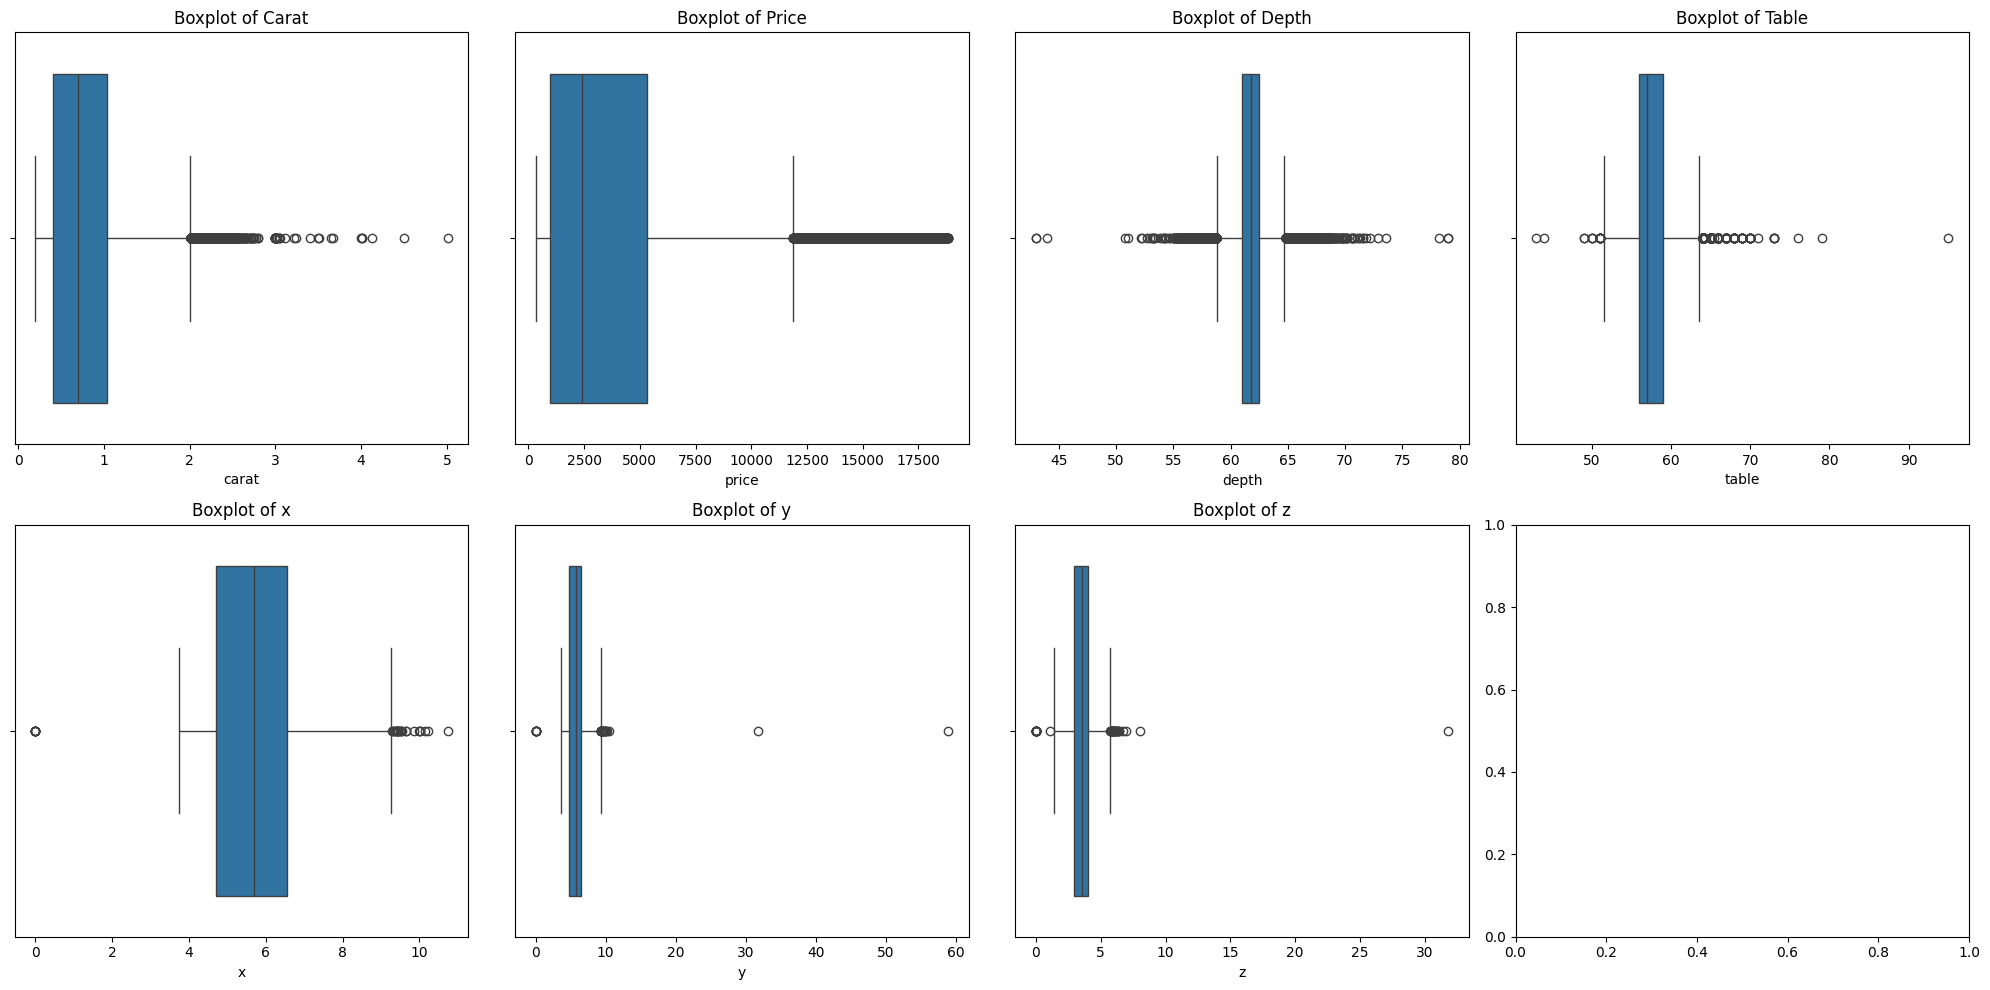

In [82]:
#outliers before the condition implementation 

fig, axs = plt.subplots(2, 4, figsize=(20, 10))

# --- Plot 1: Carat (Top-Left) ---
sns.boxplot(x=df['carat'], ax=axs[0, 0])
axs[0, 0].set_title('Boxplot of Carat')

# --- Plot 2: Price (Top-Row, 2nd plot) ---
sns.boxplot(x=df['price'], ax=axs[0, 1])
axs[0, 1].set_title('Boxplot of Price')

# --- Plot 3: Depth (Top-Row, 3rd plot) ---
sns.boxplot(x=df['depth'], ax=axs[0, 2])
axs[0, 2].set_title('Boxplot of Depth')

# --- Fill the rest of the plots ---
sns.boxplot(x=df['table'], ax=axs[0, 3])
axs[0, 3].set_title('Boxplot of Table')

sns.boxplot(x=df['x'], ax=axs[1, 0])
axs[1, 0].set_title('Boxplot of x')

sns.boxplot(x=df['y'], ax=axs[1, 1])
axs[1, 1].set_title('Boxplot of y')

sns.boxplot(x=df['z'], ax=axs[1, 2])
axs[1, 2].set_title('Boxplot of z')



plt.tight_layout()
plt.show()


In [83]:
#conditon to remove
df = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)]

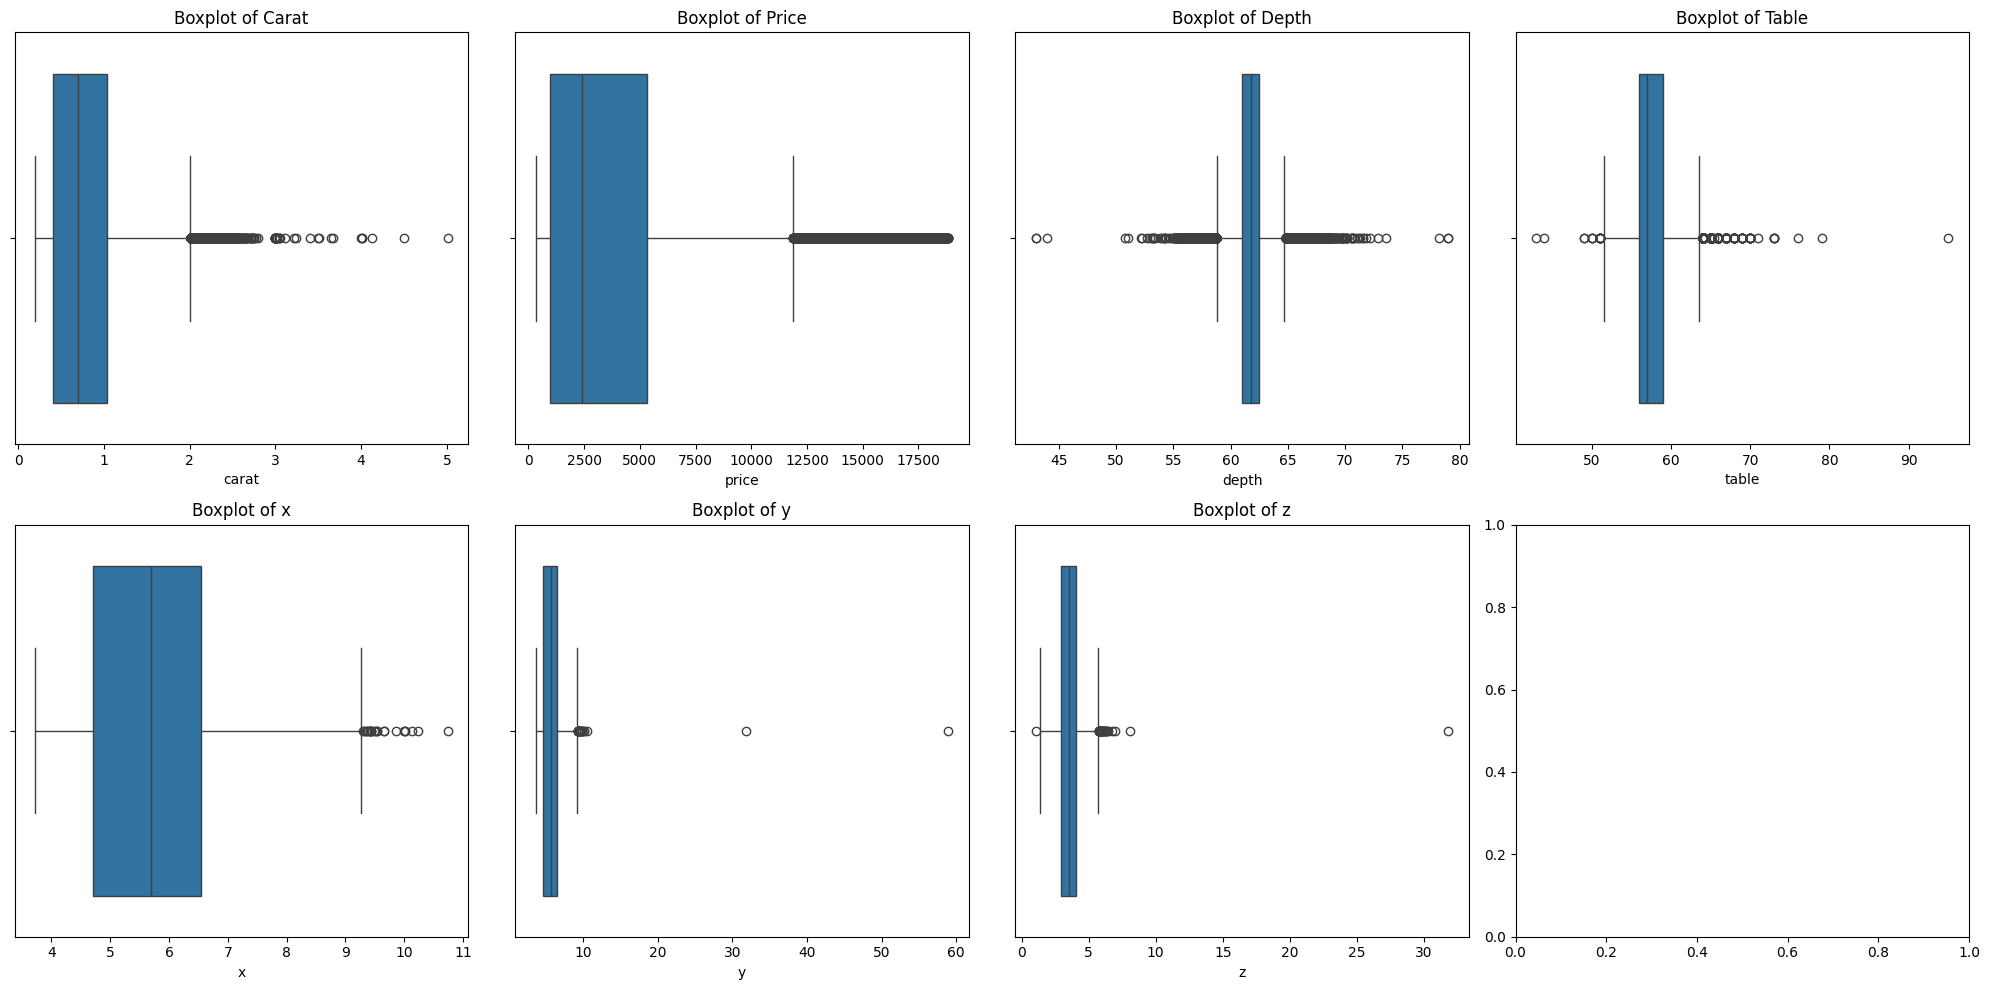

In [84]:
#outliers after the condition implementation 

fig, axs = plt.subplots(2, 4, figsize=(20, 10))

# --- Plot 1: Carat (Top-Left) ---
sns.boxplot(x=df['carat'], ax=axs[0, 0])
axs[0, 0].set_title('Boxplot of Carat')

# --- Plot 2: Price (Top-Row, 2nd plot) ---
sns.boxplot(x=df['price'], ax=axs[0, 1])
axs[0, 1].set_title('Boxplot of Price')

# --- Plot 3: Depth (Top-Row, 3rd plot) ---
sns.boxplot(x=df['depth'], ax=axs[0, 2])
axs[0, 2].set_title('Boxplot of Depth')

# --- Fill the rest of the plots ---
sns.boxplot(x=df['table'], ax=axs[0, 3])
axs[0, 3].set_title('Boxplot of Table')

sns.boxplot(x=df['x'], ax=axs[1, 0])
axs[1, 0].set_title('Boxplot of x')

sns.boxplot(x=df['y'], ax=axs[1, 1])
axs[1, 1].set_title('Boxplot of y')

sns.boxplot(x=df['z'], ax=axs[1, 2])
axs[1, 2].set_title('Boxplot of z')



plt.tight_layout()
plt.show()


In [85]:
df.shape

(53920, 10)

In [86]:
# 3. Ab Statistical Outliers ko hatayein (IQR Method)
numerical_cols = [ 'depth', 'table', 'x', 'y', 'z']

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Condition banao
    condition = (df[col] >= lower_bound) & (df[col] <= upper_bound)

    df = df[condition]

print(f"Size after removing statistical outliers: {df.shape}")



Size after removing statistical outliers: (50967, 10)


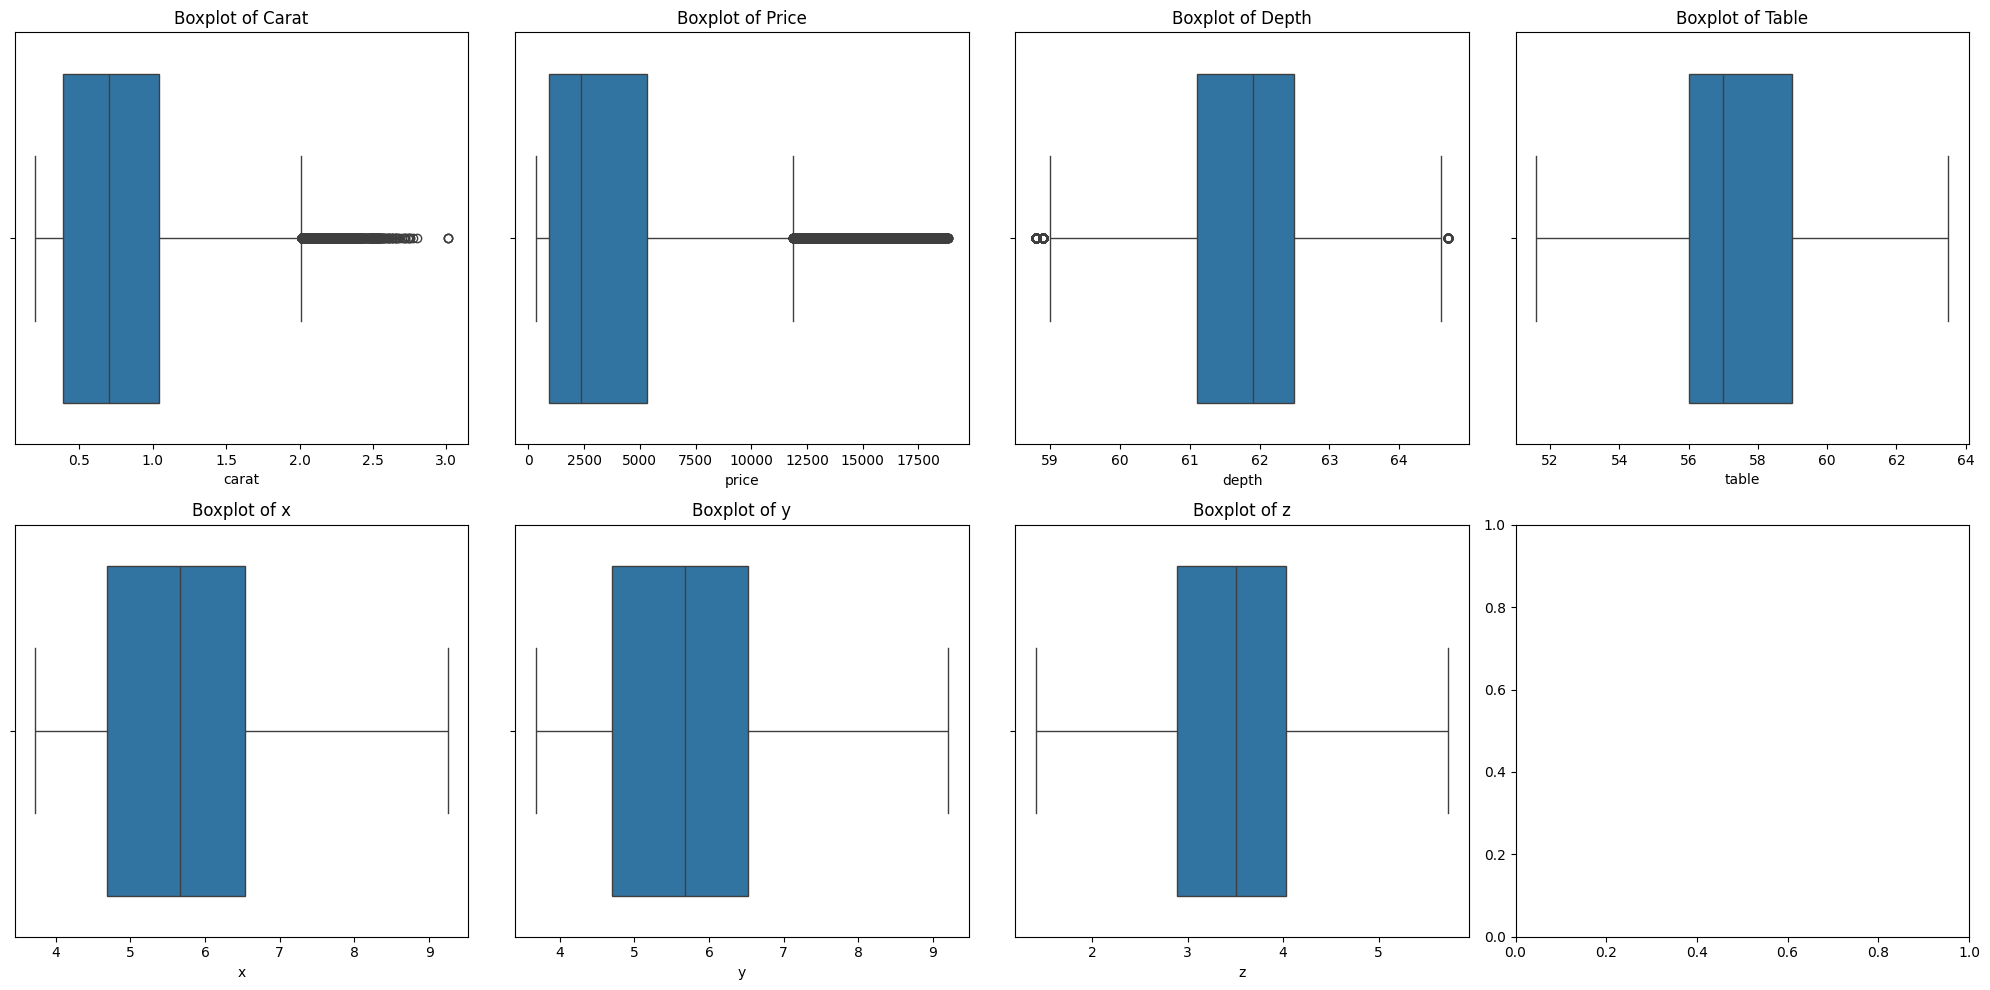

In [87]:
#outliers after the condition implementation 

fig, axs = plt.subplots(2, 4, figsize=(20, 10))

# --- Plot 1: Carat (Top-Left) ---
sns.boxplot(x=df['carat'], ax=axs[0, 0])
axs[0, 0].set_title('Boxplot of Carat')

# --- Plot 2: Price (Top-Row, 2nd plot) ---
sns.boxplot(x=df['price'], ax=axs[0, 1])
axs[0, 1].set_title('Boxplot of Price')

# --- Plot 3: Depth (Top-Row, 3rd plot) ---
sns.boxplot(x=df['depth'], ax=axs[0, 2])
axs[0, 2].set_title('Boxplot of Depth')

# --- Fill the rest of the plots ---
sns.boxplot(x=df['table'], ax=axs[0, 3])
axs[0, 3].set_title('Boxplot of Table')

sns.boxplot(x=df['x'], ax=axs[1, 0])
axs[1, 0].set_title('Boxplot of x')

sns.boxplot(x=df['y'], ax=axs[1, 1])
axs[1, 1].set_title('Boxplot of y')

sns.boxplot(x=df['z'], ax=axs[1, 2])
axs[1, 2].set_title('Boxplot of z')



plt.tight_layout()
plt.show()


In [88]:
le=LabelEncoder()
df['cut']=le.fit_transform(df['cut'])

In [89]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.29,3,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,0.24,4,J,VVS2,62.8,57.0,336,3.94,3.96,2.48


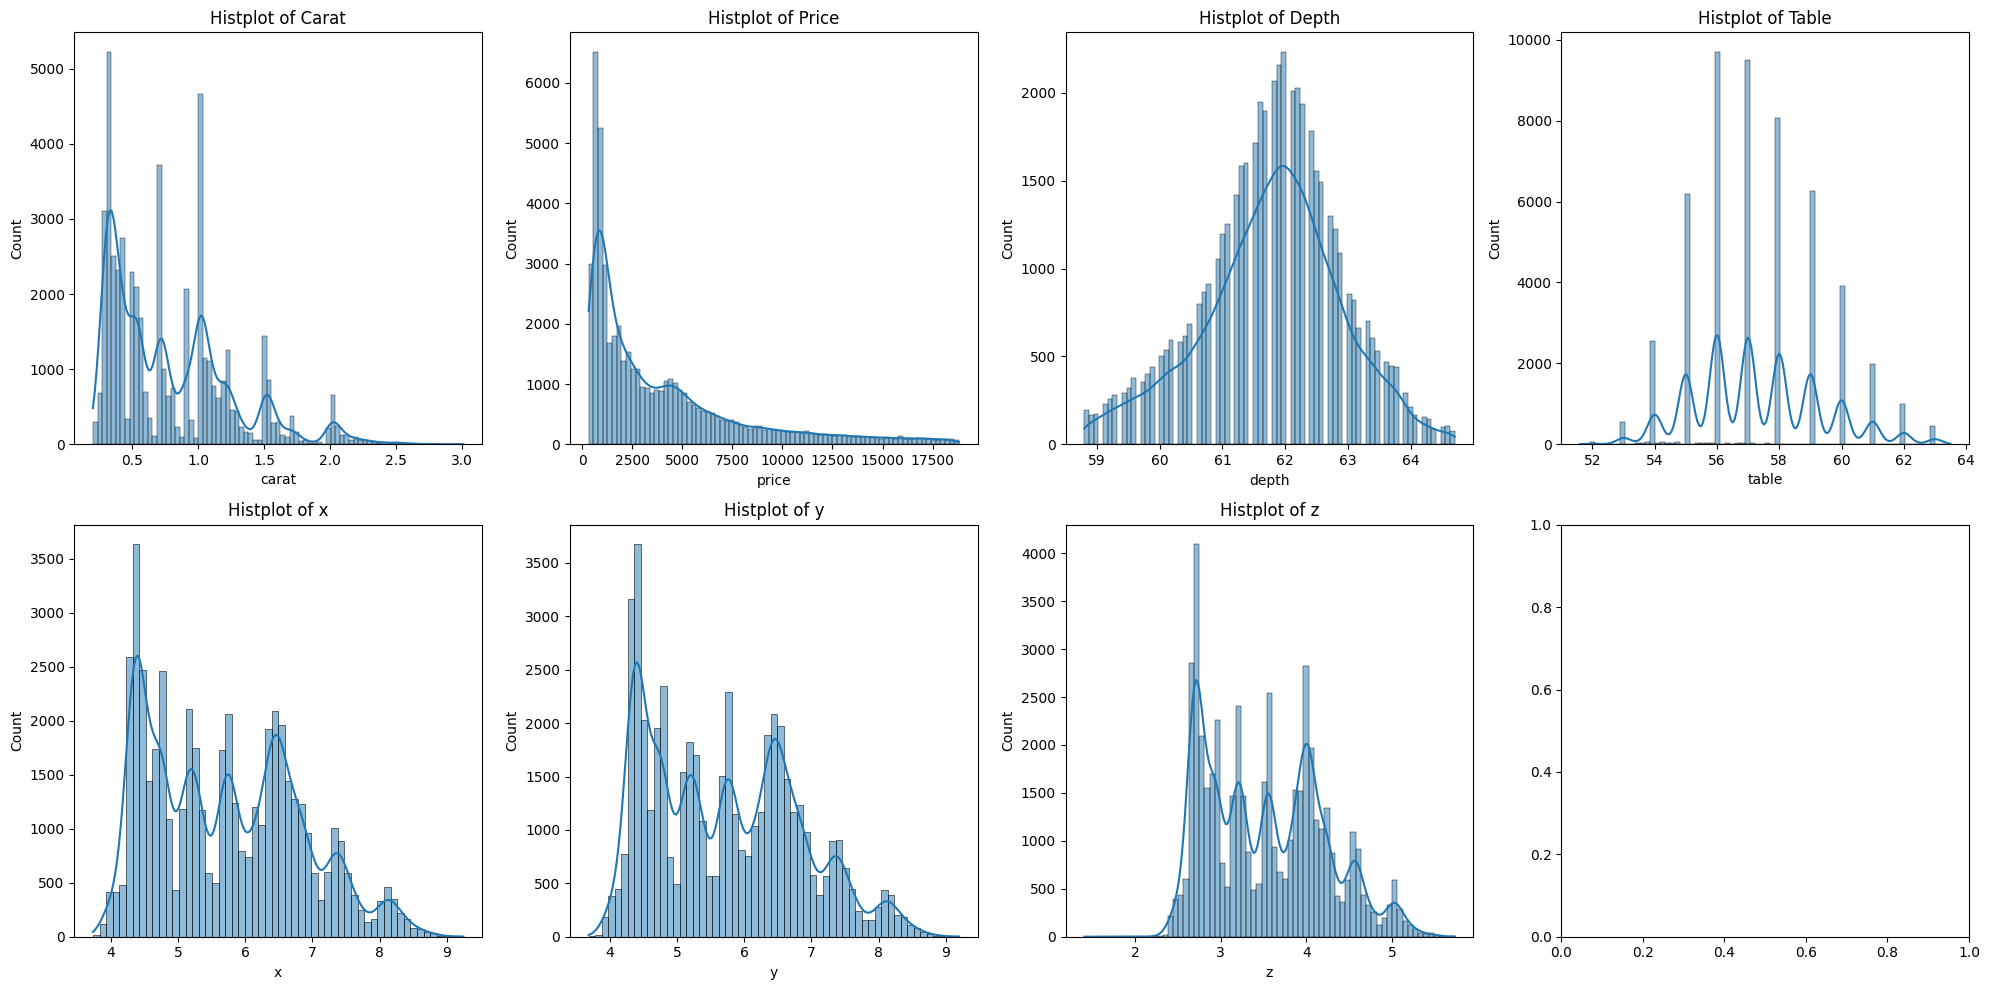

In [90]:
fig, axs = plt.subplots(2, 4, figsize=(20, 10))

# --- Plot 1: Carat (Top-Left) ---
sns.histplot(data=df['carat'],kde=True, ax=axs[0, 0])
axs[0, 0].set_title('Histplot of Carat')

# --- Plot 2: Price (Top-Row, 2nd plot) ---
sns.histplot(data=df['price'],kde=True, ax=axs[0, 1])
axs[0, 1].set_title('Histplot of Price')

# --- Plot 3: Depth (Top-Row, 3rd plot) ---
sns.histplot(data=df['depth'],kde=True, ax=axs[0, 2])
axs[0, 2].set_title('Histplot of Depth')

# --- Fill the rest of the plots ---
sns.histplot(data=df['table'],kde=True, ax=axs[0, 3])
axs[0, 3].set_title('Histplot of Table')

sns.histplot(data=df['x'], kde=True,ax=axs[1, 0])
axs[1, 0].set_title('Histplot of x')

sns.histplot(data=df['y'], kde=True,ax=axs[1, 1])
axs[1, 1].set_title('Histplot of y')

sns.histplot(data=df['z'], kde=True,ax=axs[1, 2])
axs[1, 2].set_title('Histplot of z')



plt.tight_layout()
plt.show()


In [91]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.29,3,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,0.24,4,J,VVS2,62.8,57.0,336,3.94,3.96,2.48


In [92]:
X = df.drop(columns=['cut'],axis=1)
y = df['cut']

In [93]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [94]:
X_train.shape

(40773, 9)

In [95]:
X_test.shape

(10194, 9)

In [96]:
transformer=ColumnTransformer(transformers=[
    ('num',PowerTransformer(method='yeo-johnson'),['carat', 'depth', 'table', 'price', 'x', 'y', 'z']),
    ('cat',OneHotEncoder(sparse_output=False,drop='first'),['color','clarity'])
],remainder='passthrough')

In [97]:
X_train_trans=transformer.fit_transform(X_train)

In [98]:
X_test_trans=transformer.transform(X_test)

In [99]:
pd.DataFrame(X_train_trans).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,-0.225667,-0.116670,-1.790575,-0.647857,-0.149369,-0.097984,-0.133769,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,-0.382581,0.342424,-1.175952,-0.191844,-0.328586,-0.285782,-0.277192,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.744785,-0.206361,-0.605790,0.063407,0.755935,0.739948,0.734228,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.158495,1.726205,-0.076174,0.231672,0.132191,0.145297,0.282333,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,-0.811812,-0.383651,-1.175952,-0.780988,-0.769349,-0.757372,-0.794345,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


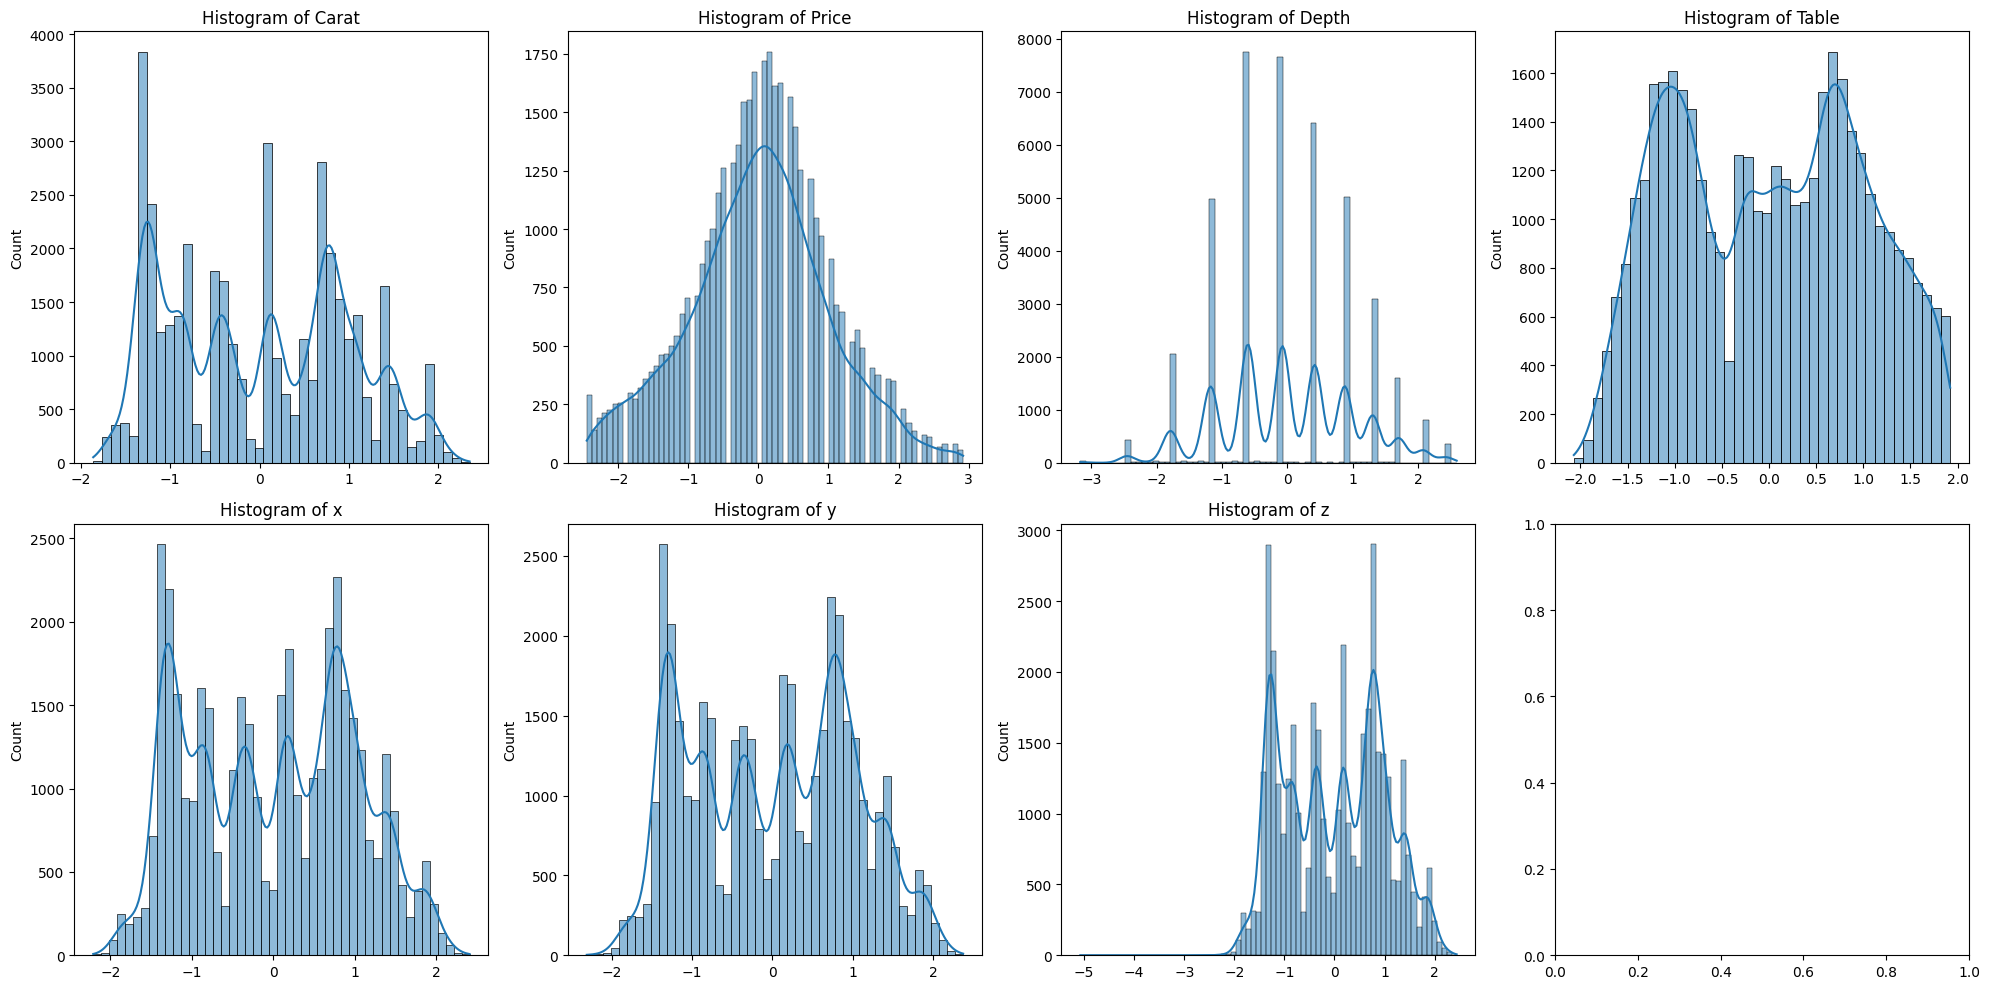

In [100]:
fig, axs = plt.subplots(2, 4, figsize=(20, 10))

sns.histplot(X_train_trans[:, 0], kde=True, ax=axs[0, 0])
axs[0, 0].set_title('Histogram of Carat')

sns.histplot(X_train_trans[:, 1], kde=True, ax=axs[0, 1])
axs[0, 1].set_title('Histogram of Price')

sns.histplot(X_train_trans[:, 2], kde=True, ax=axs[0, 2])
axs[0, 2].set_title('Histogram of Depth')

sns.histplot(X_train_trans[:, 3], kde=True, ax=axs[0, 3])
axs[0, 3].set_title('Histogram of Table')

sns.histplot(X_train_trans[:, 4], kde=True, ax=axs[1, 0])
axs[1, 0].set_title('Histogram of x')

sns.histplot(X_train_trans[:, 5], kde=True, ax=axs[1, 1])
axs[1, 1].set_title('Histogram of y')

sns.histplot(X_train_trans[:, 6], kde=True, ax=axs[1, 2])
axs[1, 2].set_title('Histogram of z')

plt.tight_layout()
plt.show()


In [101]:
knn = KNeighborsClassifier(n_neighbors=132,weights='distance',metric='minkowski', p=2,algorithm='auto')

In [102]:
knn.fit(X_train_trans, y_train)

,n_neighbors,132
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [103]:
y_pred = knn.predict(X_test_trans)
accuracy_score(y_test,y_pred)

0.7023739454581126

In [104]:
# Yeh code X_train_trans, y_train, X_test_trans, y_test 
# ke defined hone ke baad chalega

scores_list = []
best_score = 0
best_params = {}

print("Hyper tuning shuru kar raha hoon...")

for k in range(1, 150): # Aapka loop
    for w in ['uniform', 'distance']: # weights ke liye loop
        for p_val in [1, 2]: # p (distance) ke liye loop
            
            # Model ko naye parameters ke saath train karein
            knn = KNeighborsClassifier(n_neighbors=k, weights=w, p=p_val, n_jobs=-1)
            knn.fit(X_train_trans, y_train)
            
            # Test set par predict karein
            y_pred = knn.predict(X_test_trans)
            score = accuracy_score(y_test, y_pred)
            
            # Score ko list mein daalein
            scores_list.append({'k': k, 'weights': w, 'p': p_val, 'score': score})
            
            # Best score check karein
            if score > best_score:
                best_score = score
                best_params = {'k': k, 'weights': w, 'p': p_val, 'score': score}

print("Hyper tuning poora hua.")
print(f"Sabse accha result: {best_params}")



Hyper tuning shuru kar raha hoon...
Hyper tuning poora hua.
Sabse accha result: {'k': 132, 'weights': 'distance', 'p': 2, 'score': 0.7023739454581126}


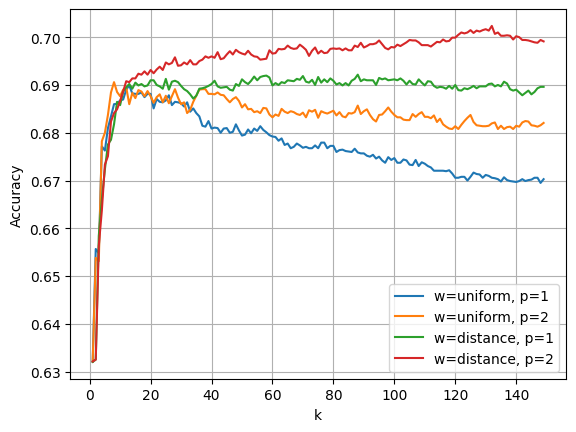

In [105]:
scores_df = pd.DataFrame(scores_list)
for w in ['uniform', 'distance']:
    for p_val in [1, 2]:
        temp_df = scores_df[(scores_df['weights'] == w) & (scores_df['p'] == p_val)]
        plt.plot(temp_df['k'], temp_df['score'], label=f'w={w}, p={p_val}')
plt.legend()
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

In [106]:
pipeline = Pipeline([
    ('preprocessor', transformer),
    ('classifier', KNeighborsClassifier(n_jobs=-1)) # n_jobs=-1 to speed up KNN
])

In [107]:
search_spaces = {
    'classifier__n_neighbors': Integer(1, 300),
    'classifier__weights': Categorical(['uniform', 'distance']),
    'classifier__p': Categorical([1, 2])  # 1 for Manhattan distance, 2 for Euclidean
}

In [108]:
bayes_search = BayesSearchCV(
    estimator=pipeline,
    search_spaces=search_spaces,
    n_iter=50,          # Number of parameter settings to sample
    scoring='accuracy',
    cv=3,               # 3-fold cross-validation
    n_jobs=-1,          # Use all available cores
    random_state=42,    # For reproducible results
    verbose=1           # To see the progress
)
print("Starting BayesianSearchCV... This will take a few minutes.")
bayes_search.fit(X_train, y_train)
print("BayesianSearchCV complete.")

Starting BayesianSearchCV... This will take a few minutes.
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

In [109]:
bayes_search.best_params_

OrderedDict([('classifier__n_neighbors', 108),
             ('classifier__p', 2),
             ('classifier__weights', 'distance')])

In [110]:
bayes_search.best_score_

np.float64(0.6842518333210702)

In [111]:
test_accuracy = bayes_search.score(X_test, y_test)

In [112]:
test_accuracy

0.6989405532666274

In [113]:
for cols in ['color','clarity']:
    le=LabelEncoder()
    dia[cols]=le.fit_transform(dia[cols])

np.random.seed(43)
ran=np.random.choice(dia.index, size=int(0.91*len(dia)), replace=False)
print(dia.info())

scaler=MinMaxScaler()
columns_for_norm=['depth','table','price','x','y','z']
dia_norm=pd.DataFrame(scaler.fit_transform(dia[columns_for_norm]), columns=columns_for_norm)


#Original Data Summ
print("\nOriginal Data Summ\n")
print(dia.describe())
print("\nNormalised Data Summ\n")
print(dia_norm.describe())


#columns_for_training=['depth','x','y','z']
dia_train=dia_norm.loc[ran,:]
dia_test=dia_norm.drop(ran)
dia_target_cat=dia.iloc[ran, 1]
dia_test_cat=dia.drop(ran)['cut']

#KNN
knn=KNeighborsClassifier(n_neighbors=32,metric='manhattan')
knn.fit(dia_train, dia_target_cat)
pr=knn.predict(dia_test)

#Confusion Matrix
matrix1=confusion_matrix(dia_test_cat, pr)
print("\nConfusion Matrix\n",matrix1)


#Accuracy Score
ac1=accuracy_score(dia_test_cat, pr)*100
print("\nAccuracy: {:.2f}".format(ac1))


NameError: name 'dia' is not defined